In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exact_sol(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

def backward_euler(h, t_end=30):
    t_values = np.arange(0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = 0  # Initial condition y(0) = 0
    
    for i in range(len(t_values) - 1):
        t_next = t_values[i+1]
        # Using the derived algebraic formula
        numerator = y_values[i] + 3000*h - 2000*h*np.exp(-t_next)
        denominator = 1 + 1000*h
        y_values[i+1] = numerator / denominator
        
    return t_values, y_values

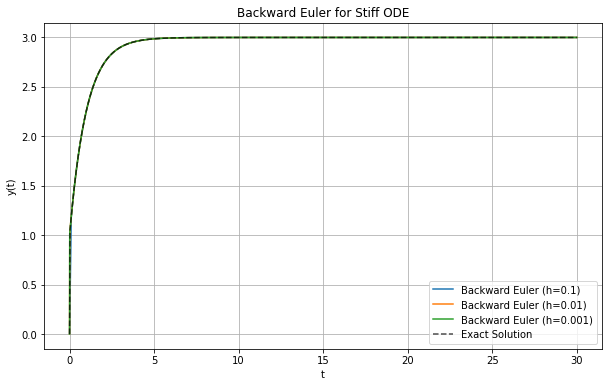

In [2]:
# Step sizes to test
h_list = [0.1, 0.01, 0.001]

plt.figure(figsize=(10, 6))

# Plot Backward Euler for each h
for h in h_list:
    t, y = backward_euler(h)
    plt.plot(t, y, label=f'Backward Euler (h={h})')

# Plot Exact Solution for comparison
t_exact = np.linspace(0, 30, 1000)
plt.plot(t_exact, exact_sol(t_exact), 'k--', label='Exact Solution', alpha=0.7)

plt.title("Backward Euler for Stiff ODE")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()